In [1]:
import numpy as np
import pandas as pd
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
import matplotlib.pyplot as plt

In [2]:
iris = load_iris()
X = iris.data
y = iris.target

In [3]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

In [4]:
knn = KNeighborsClassifier()


In [5]:
param_grid = {
    'n_neighbors': np.arange(1, 31),   # Try k from 1 to 30
    'weights': ['uniform', 'distance'] # Try both weighting schemes
}

In [6]:
grid = GridSearchCV(
    estimator=knn,             # Model to tune
    param_grid=param_grid,     # Parameters to search
    cv=5,                      # 5-fold cross validation
    scoring='accuracy',        # Metric to optimize
    return_train_score=True,   # Also return training scores
    n_jobs=-1                  # Use all cores for speed
)


In [7]:
grid.fit(X_train, y_train)

GridSearchCV(cv=5, estimator=KNeighborsClassifier(), n_jobs=-1,
             param_grid={'n_neighbors': array([ 1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16, 17,
       18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30]),
                         'weights': ['uniform', 'distance']},
             return_train_score=True, scoring='accuracy')

In [8]:
print("=== Best Parameters Found ===")
print(grid.best_params_)
print(f"Best Cross-Validation Accuracy: {grid.best_score_:.4f}")



=== Best Parameters Found ===
{'n_neighbors': np.int64(18), 'weights': 'distance'}
Best Cross-Validation Accuracy: 0.9619


In [9]:
best_knn = grid.best_estimator_
y_pred = best_knn.predict(X_test)

In [10]:
print("\n=== Evaluation on Test Set ===")
print(f"Test Accuracy: {accuracy_score(y_test, y_pred):.4f}")
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("Classification Report:\n", classification_report(y_test, y_pred))




=== Evaluation on Test Set ===
Test Accuracy: 1.0000
Confusion Matrix:
 [[19  0  0]
 [ 0 13  0]
 [ 0  0 13]]
Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00        19
           1       1.00      1.00      1.00        13
           2       1.00      1.00      1.00        13

    accuracy                           1.00        45
   macro avg       1.00      1.00      1.00        45
weighted avg       1.00      1.00      1.00        45



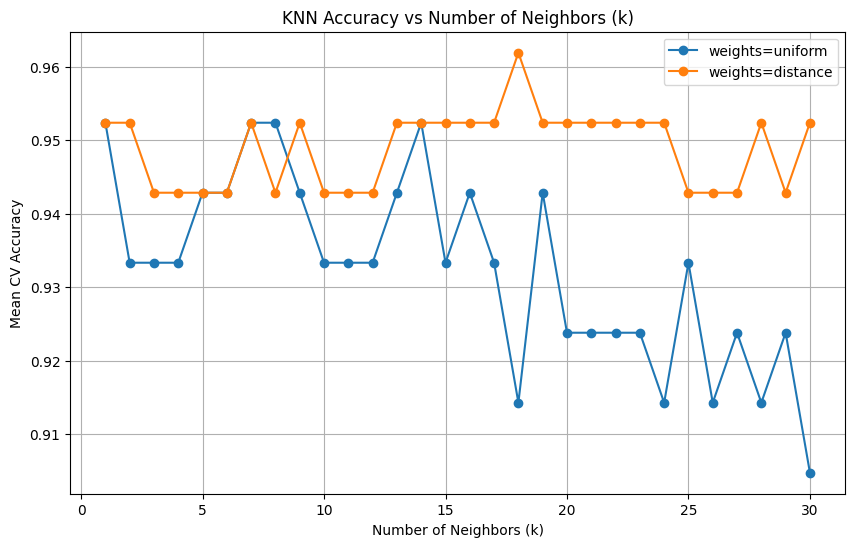

Exception ignored in: <function ResourceTracker.__del__ at 0x102bf9f80>
Traceback (most recent call last):
  File "/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/multiprocessing/resource_tracker.py", line 84, in __del__
  File "/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/multiprocessing/resource_tracker.py", line 93, in _stop
  File "/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/multiprocessing/resource_tracker.py", line 118, in _stop_locked
ChildProcessError: [Errno 10] No child processes
Exception ignored in: <function ResourceTracker.__del__ at 0x104691f80>
Traceback (most recent call last):
  File "/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/multiprocessing/resource_tracker.py", line 84, in __del__
  File "/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/multiprocessing/resource_tracker.py", line 93, in _stop
  File "/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/m

In [11]:
results = pd.DataFrame(grid.cv_results_)

plt.figure(figsize=(10,6))
for weight in ['uniform', 'distance']:
    subset = results[results['param_weights'] == weight]
    plt.plot(subset['param_n_neighbors'], subset['mean_test_score'], marker='o', label=f'weights={weight}')

plt.title('KNN Accuracy vs Number of Neighbors (k)')
plt.xlabel('Number of Neighbors (k)')
plt.ylabel('Mean CV Accuracy')
plt.legend()
plt.grid(True)
plt.show()